### Analisis y procesamiento de señales
# Trabajo Practico N^2
## Bernardita Aragon


A lo largo de este trabajo vamos a simular el comportamiento de un ADC de $B$ bits , incorporando el proceso de muestreo y la presencia de ruido en la señal de entrada.

Para realizar la simulación se utiliza una señal senoidal de potencia unitaria, muestreada a una frecuencia de $fs = 1000 Hz$, a la cual se le agrega ruido gaussiano. La potencia de este ruido se define en función de la potencia del ruido de cuantización mediante el factor $kn$, cumpliendo:

$Pr= kn*Pq$

donde:

$Pq= (q^2)/12$

El ADC trabaja con un rango analógico de $±Vf = 2v V$. A partir de estos parámetros se analizará el comportamiento de la señal antes y después de la cuantización, tanto en el dominio temporal como en frecuencia, y se observará cómo varían los resultados al modificar la cantidad de bits del ADC y el valor de $kn$.

### Inciso A
Para el primer experimento utilizaremos $B= 4  bits$ y $kn=1$.

In [2]:
#importacion de modulos
import numpy as np
import matplotlib.pyplot as plt 

#definiciones
N= 1000 #cantidad de muestras
fs=1000 #frecuencia de muestreo
ts= 1/fs #tiempo entre muestras
B= 4 #cantidad de bits
vf=2 #rango
f0= fs/N #frecuencia de la senoide
P=1 #potencia de la senoide
vmax= np.sqrt(2*P)
dc = 0
ph = 0
kn = 1  # factor de escala del ruido analogico

def mi_funcion_sen( vmax, dc, ff, ph , N, fs):
    
    tt= np.arange(0,N) / fs
    xx= dc + vmax*np.sin(2 * np.pi * ff * tt + ph)

    return(tt, xx)

tt, xx = mi_funcion_sen(vmax, dc, f0, ph, N, fs)

A partir del rango del ADC y la cantidad de bits calculo el paso de cuantización $q$. Con este valor se obtiene la potencia del ruido de cuantización $Pq$ y, usando el factor $kn$, se define la potencia del ruido analógico $Pr$.

Luego se genera un ruido gaussiano con esa potencia y se suma a la señal senoidal para obtener la entrada del ADC. Finalmente, la señal con ruido se cuantiza.

In [3]:
q = (2*vf)/(2**B) #paso de cuantizacion
Pq= (q**2)/12 #potencia de cuantizacion
Pr= kn*Pq #potencia de ruido
desvio = np.sqrt(Pr)
ruido = np.random.normal(0, desvio, N)
#senal
ruido_xx = xx + ruido
ruido_xx_q = q * np.round(ruido_xx / q) #cuantizacion

Con todo esto hecho, puedo graficar la amplitud de la señal en función del tiempo

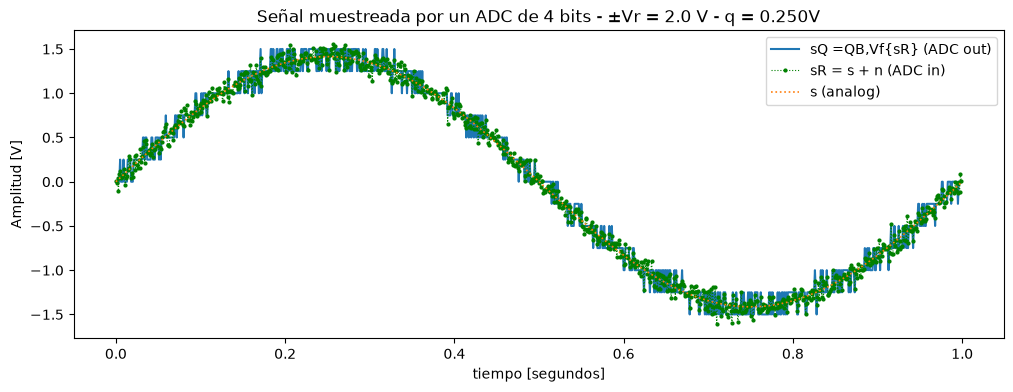

In [4]:
plt.figure(figsize=(12 , 4))
plt.plot(tt, ruido_xx_q, label="sQ =QB,Vf{sR} (ADC out)")
plt.plot(tt, ruido_xx, 'g:o', markersize=2, linewidth=0.8, label= "sR = s + n (ADC in)")
plt.plot(tt, xx, ':',linewidth=1.2, label= "s (analog)")
plt.title(f'Señal muestreada por un ADC de {B} bits - ±Vr = {vf:.1f} V - q = {q:.3f}V')
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.show()

A continuación analizamos las señales en el dominio de la frecuencia. Para esto calculamos la FFT de la señal ideal, de la señal con ruido y de la señal cuantizada, y expresamos sus potencias en dB.

También calculamos los pisos de ruido analógico y digital para poder compararlos con los espectros obtenidos.

In [5]:
#vector de frecuencias
ff_vec = np.fft.fftfreq(N, 1/fs)
ff_vec = ff_vec[:N//2] #me quedo con las frecuencias positivas hasta Nyquist

#espectros
#senal
XX = np.fft.fft(xx)/N
XX= XX[:N//2] #mismo tamano que el vector de frecuencias
PXX_mod = 2 * (np.abs(XX)**2)
PXX_mod_db = 10 * np.log10(PXX_mod + 1e-12)
#senal con ruido
R_XX = np.fft.fft(ruido_xx)/N
R_XX= R_XX[:N//2] #mismo tamano que el vector de frecuencias
PR_XX_mod = 2 * (np.abs(R_XX)**2)
PR_XX_mod_db = 10 * np.log10(PR_XX_mod + 1e-12)
#senal con ruido cuantizada
R_XX_Q = np.fft.fft(ruido_xx_q)/N
R_XX_Q= R_XX_Q[:N//2] #mismo tamano que el vector de frecuencias
PR_XX_Q_mod = 2 * (np.abs(R_XX_Q)**2)
PR_XX_Q_mod_db = 10 * np.log10(PR_XX_Q_mod + 1e-12)

#pisos de ruido
piso_analogico = 10 * np.log10(Pr/(N/2) + 1e-12)
piso_digital = 10 * np.log10(Pq/(N/2) + 1e-12)

print("Piso analogico:", piso_analogico, "dB")
print("Piso digital:", piso_digital, "dB")

Piso analogico: -49.82271191347301 dB
Piso digital: -49.82271191347301 dB


Con estos datos ya calculados, se pueden comparar las señales en el dominio de la frecuencia y observar la relación entre el piso de ruido y el espectro de la salida del ADC; para ello vamos a graficarlos.

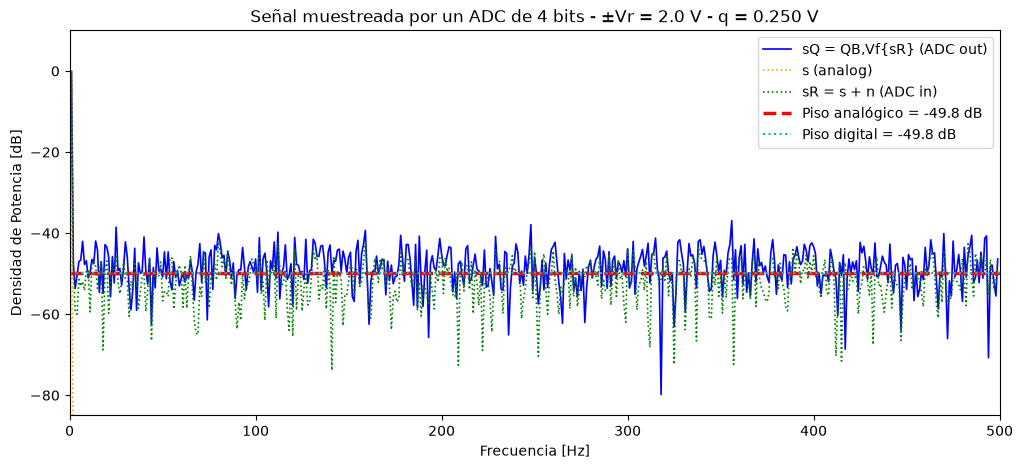

In [8]:
plt.figure(figsize=(12,5))

plt.plot(ff_vec, PR_XX_Q_mod_db, color='b', linewidth=1.2, label="sQ = QB,Vf{sR} (ADC out)")

plt.plot(ff_vec, PXX_mod_db, color='orange', linestyle=':', linewidth=1.2, label="s (analog)")

plt.plot(ff_vec, PR_XX_mod_db, color='g', linestyle=':',linewidth=1.2, label="sR = s + n (ADC in)")

plt.axhline(piso_analogico, color='r', linestyle='--',linewidth=2.5, label=f"Piso analógico = {piso_analogico:.1f} dB")

plt.axhline(piso_digital, color='c', linestyle=':', linewidth=1.5, label=f"Piso digital = {piso_digital:.1f} dB")

plt.title(f'Señal muestreada por un ADC de {B} bits - ±Vr = {vf:.1f} V - q = {q:.3f} V')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlim(0, fs/2)
plt.ylim(-85, 10)
plt.legend()
plt.show()

En el gráfico se puede ver que el piso de ruido analógico y el piso de ruido digital quedan prácticamente superpuestos. Esto coincide con los valores que obtuvimos al imprimirlos, ya que ambos dieron aproximadamente $-49.8 dB$. Como $Pr = kn*Pq$ y en este caso $kn = 1$, resulta $Pr = Pq$, por eso los dos pisos tienen el mismo valor. Además, este resultado coincide con el valor teórico esperado para este caso.

Para finalizar este inciso vamos a graficar el histograma del error de cuantización.

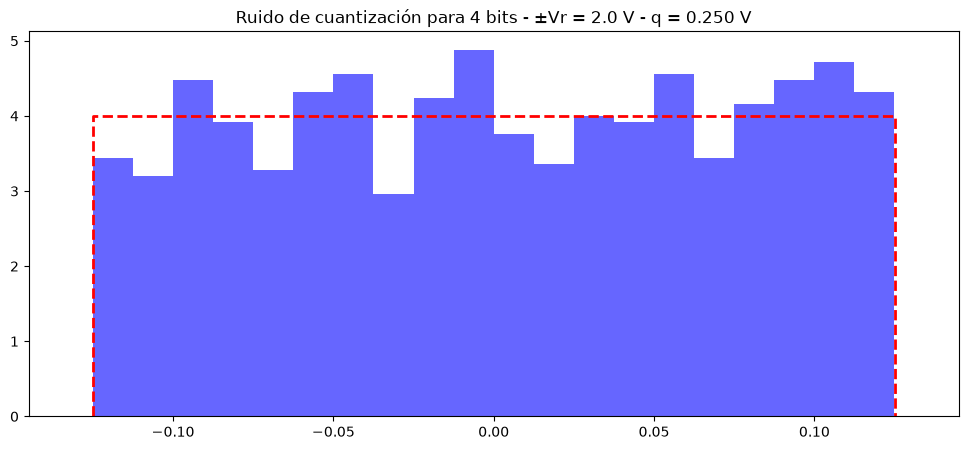

In [7]:
eq = ruido_xx_q - ruido_xx #error ruido de cuantizacion

plt.figure(figsize=(12,5))

plt.hist(eq, bins=20, density=True, color='b', alpha=0.6)

#distribucion uniforme teorica
plt.plot([-q/2, -q/2, q/2, q/2], [0, 1/q, 1/q, 0], color='r', linestyle='--', linewidth=2)

plt.title(f'Ruido de cuantización para {B} bits - ±Vr = {vf:.1f} V - q = {q:.3f} V')
plt.xlim(-q/2 - 0.02, q/2 + 0.02)
plt.show()

En el histograma se observa que el error de cuantización queda comprendido aproximadamente entre $-q/2$ y $q/2$, que para este caso corresponde a  $q=±0,125V$. Los valores se distribuyen de manera aproximadamente uniforme dentro de ese intervalo y siguen bastante bien la distribución uniforme teórica representada en rojo. Esto coincide con el comportamiento esperado para el ruido de cuantización.

### Inciso B

En este inciso vamos a repetir el procedimiento anterior modificando la cantidad de bits del ADC y el valor de $kn$. Para esto vamos a trabajar con:

- $B = 4,8,16$ bits
- $kn = 0.1,\ 1,\ 10$

De esta manera podemos comparar cómo afecta la cantidad de bits al proceso de cuantización y cómo cambia el ruido analógico al variar $kn$.

Como son varias combinaciones, voy a utilizar dos `for` para realizar el mismo procedimiento para cada caso, evitando repetir el código. El caso $B=4$ bits y $k_n=1$ no se vuelve a calcular porque ya fue analizado en el inciso A.

B = 4 - kn = 0.1
Piso analogico: -59.82271233039568 dB
Piso digital: -49.82271233039569 dB


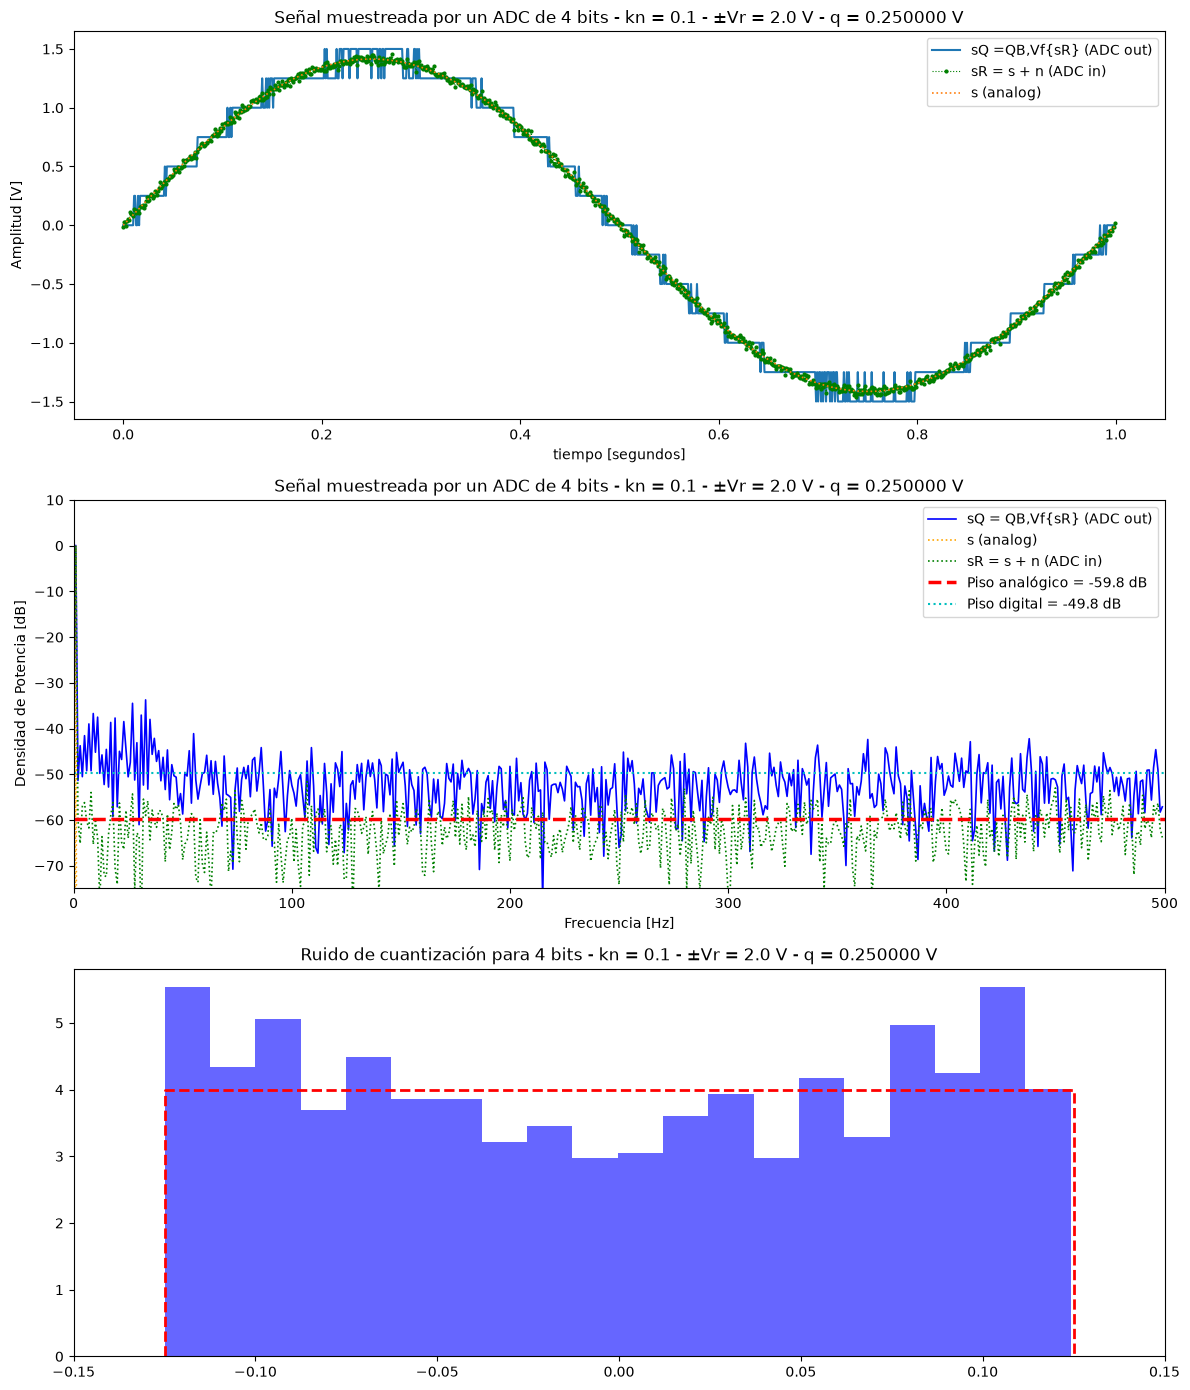

B = 4 - kn = 10
Piso analogico: -39.82271233039568 dB
Piso digital: -49.82271233039569 dB


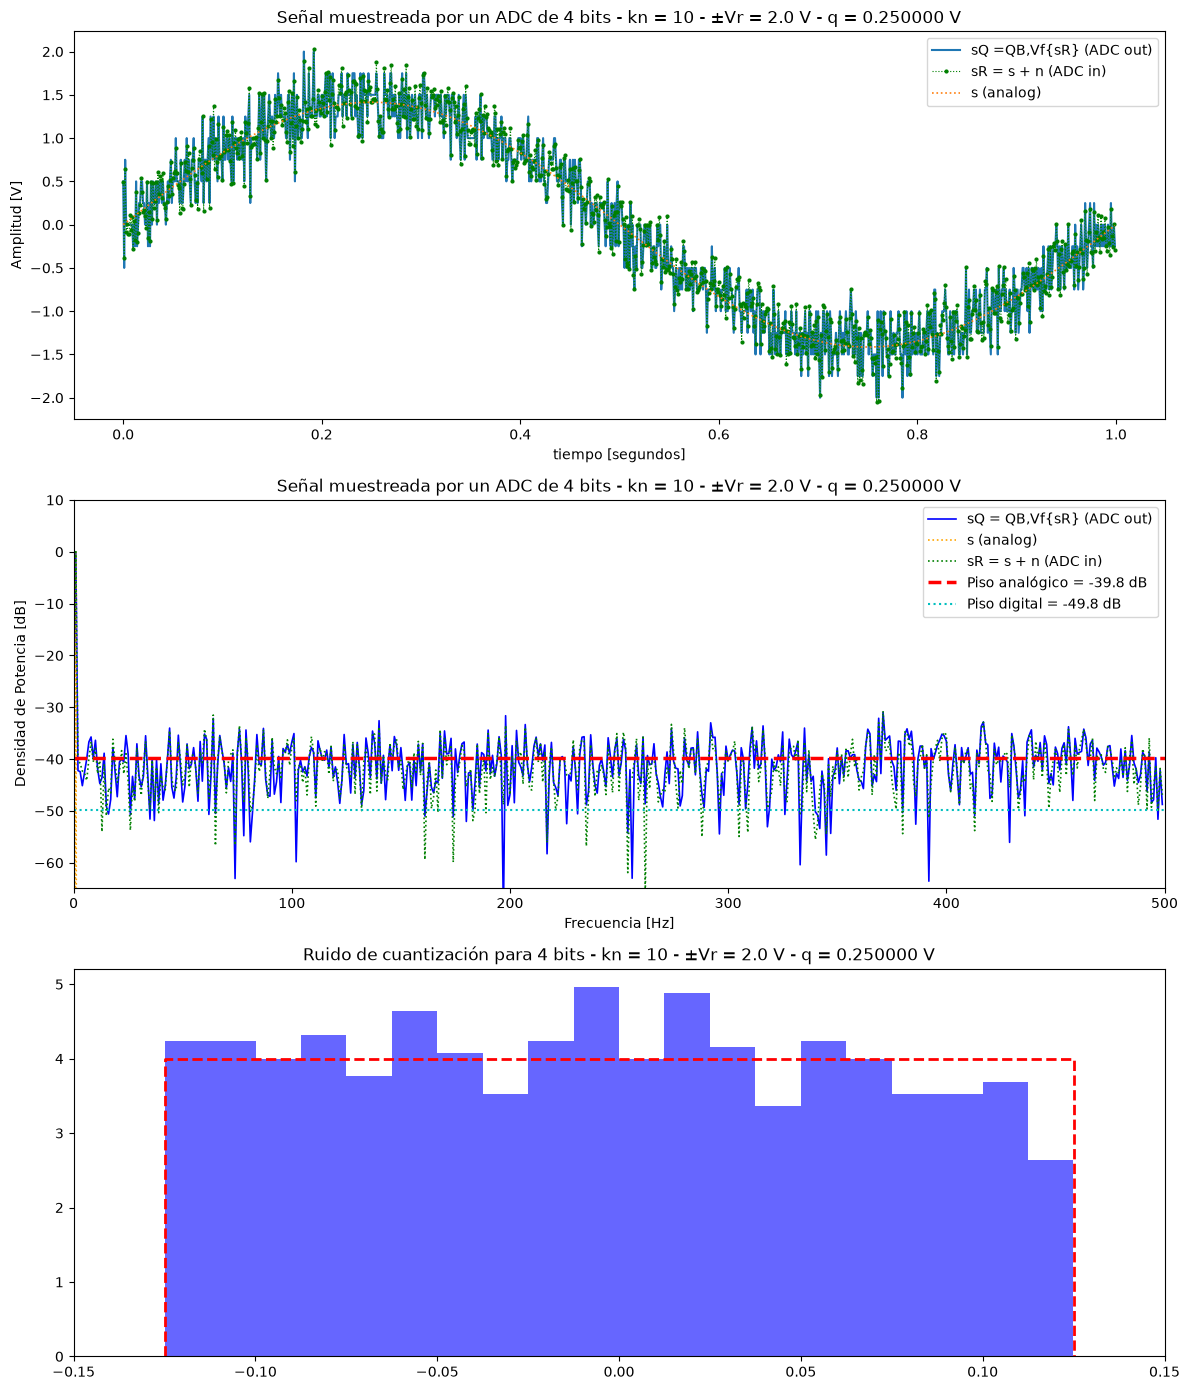

B = 8 - kn = 0.1
Piso analogico: -83.90511198351417 dB
Piso digital: -73.90511198351417 dB


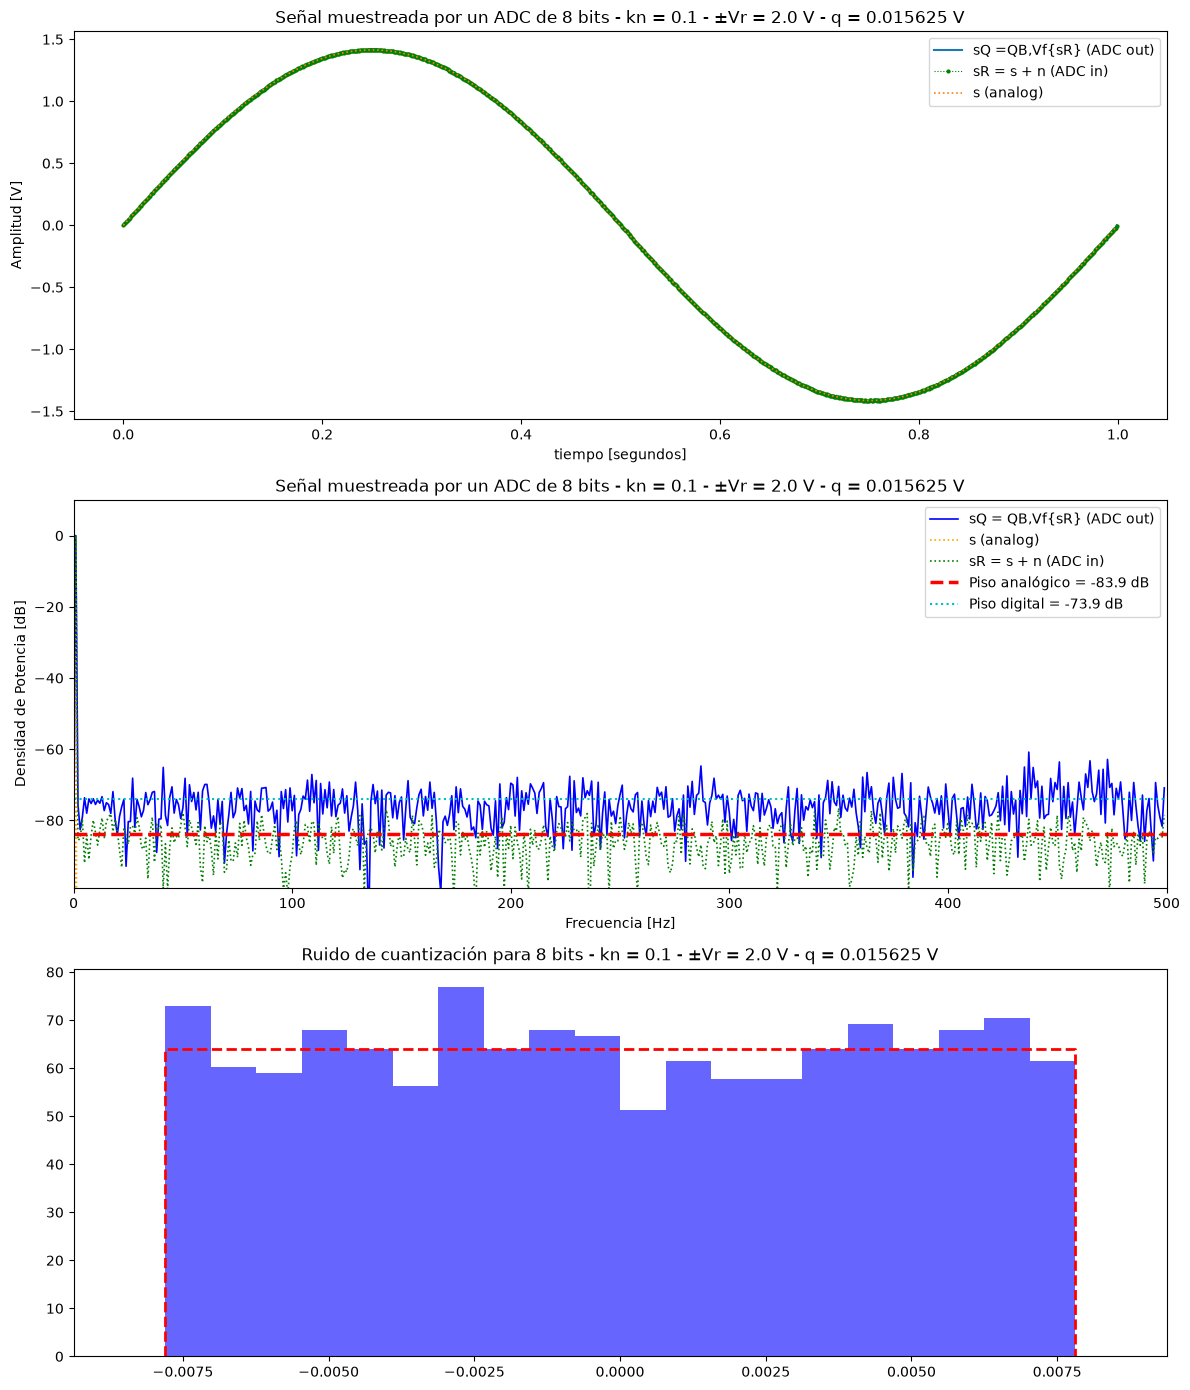

B = 8 - kn = 1
Piso analogico: -73.90511198351417 dB
Piso digital: -73.90511198351417 dB


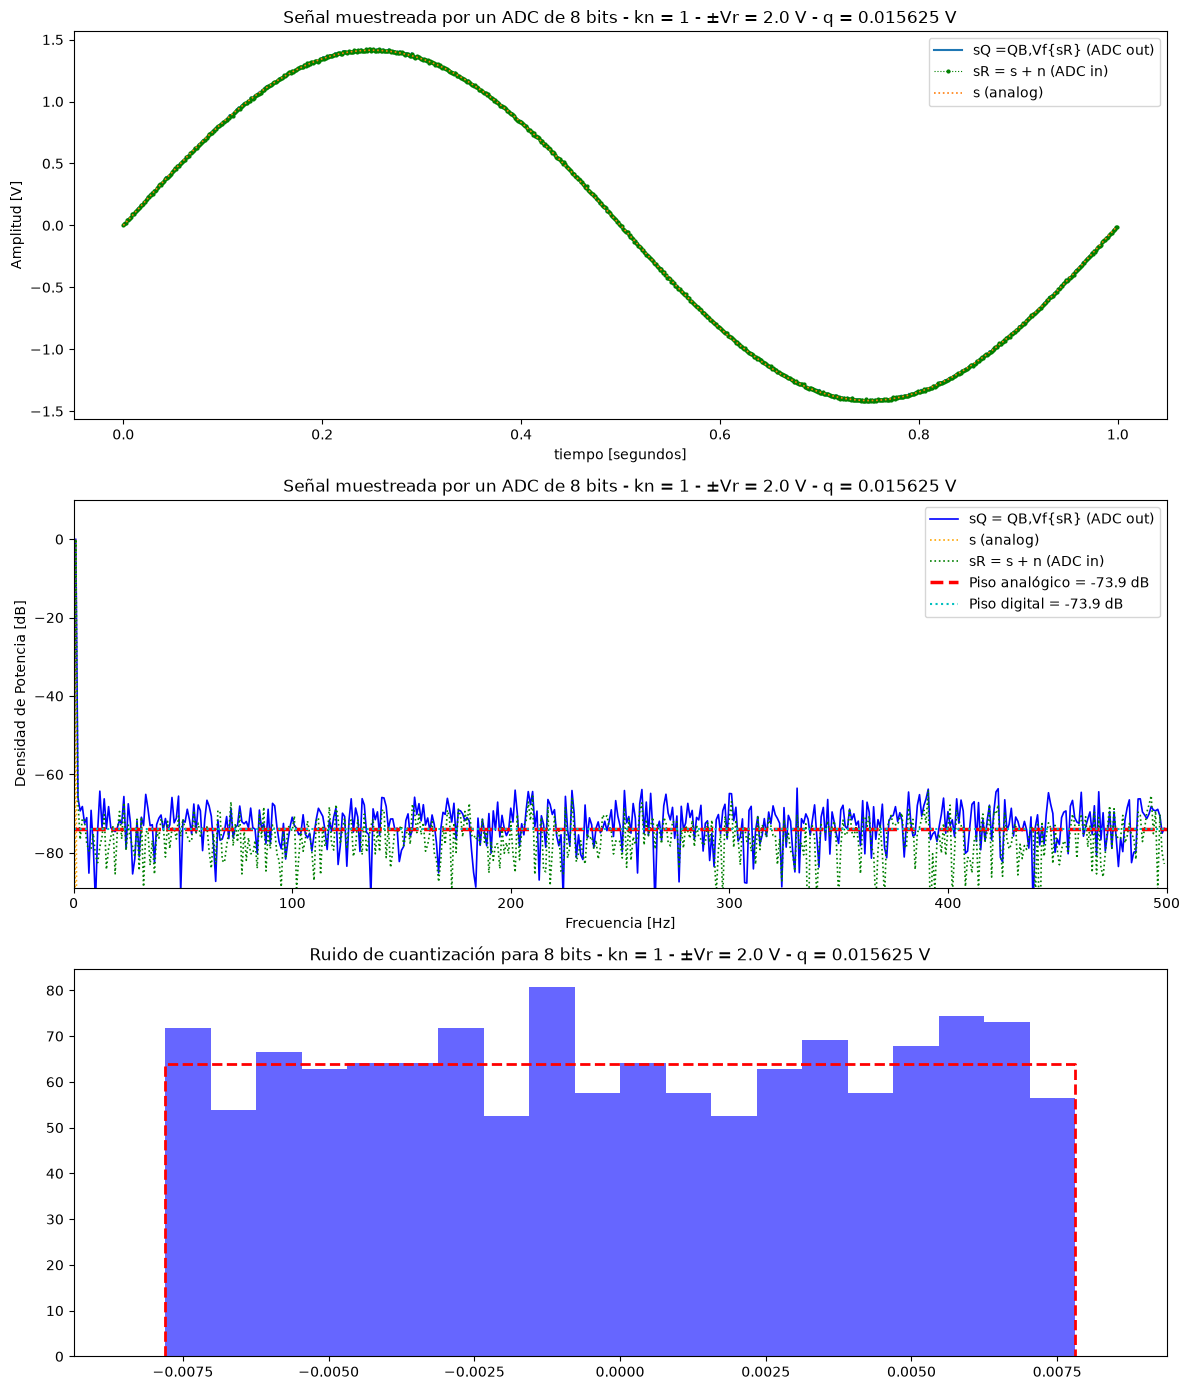

B = 8 - kn = 10
Piso analogico: -63.90511198351418 dB
Piso digital: -73.90511198351417 dB


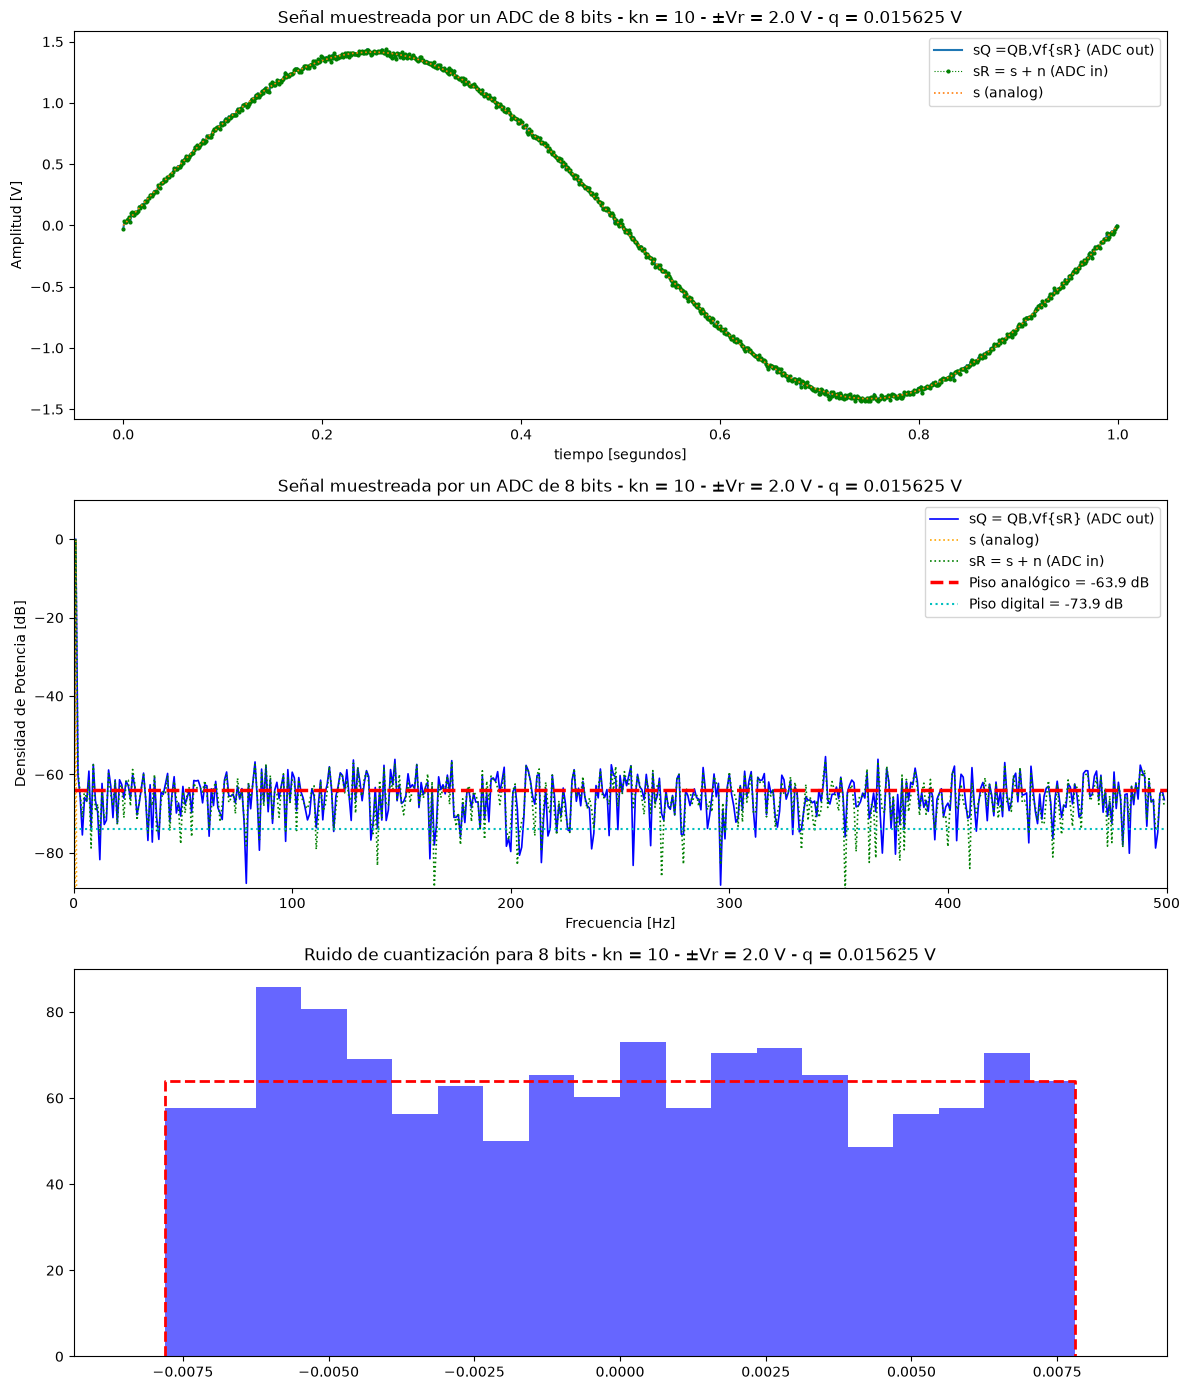

B = 16 - kn = 0.1
Piso analogico: -132.06991128975116 dB
Piso digital: -122.06991128975118 dB


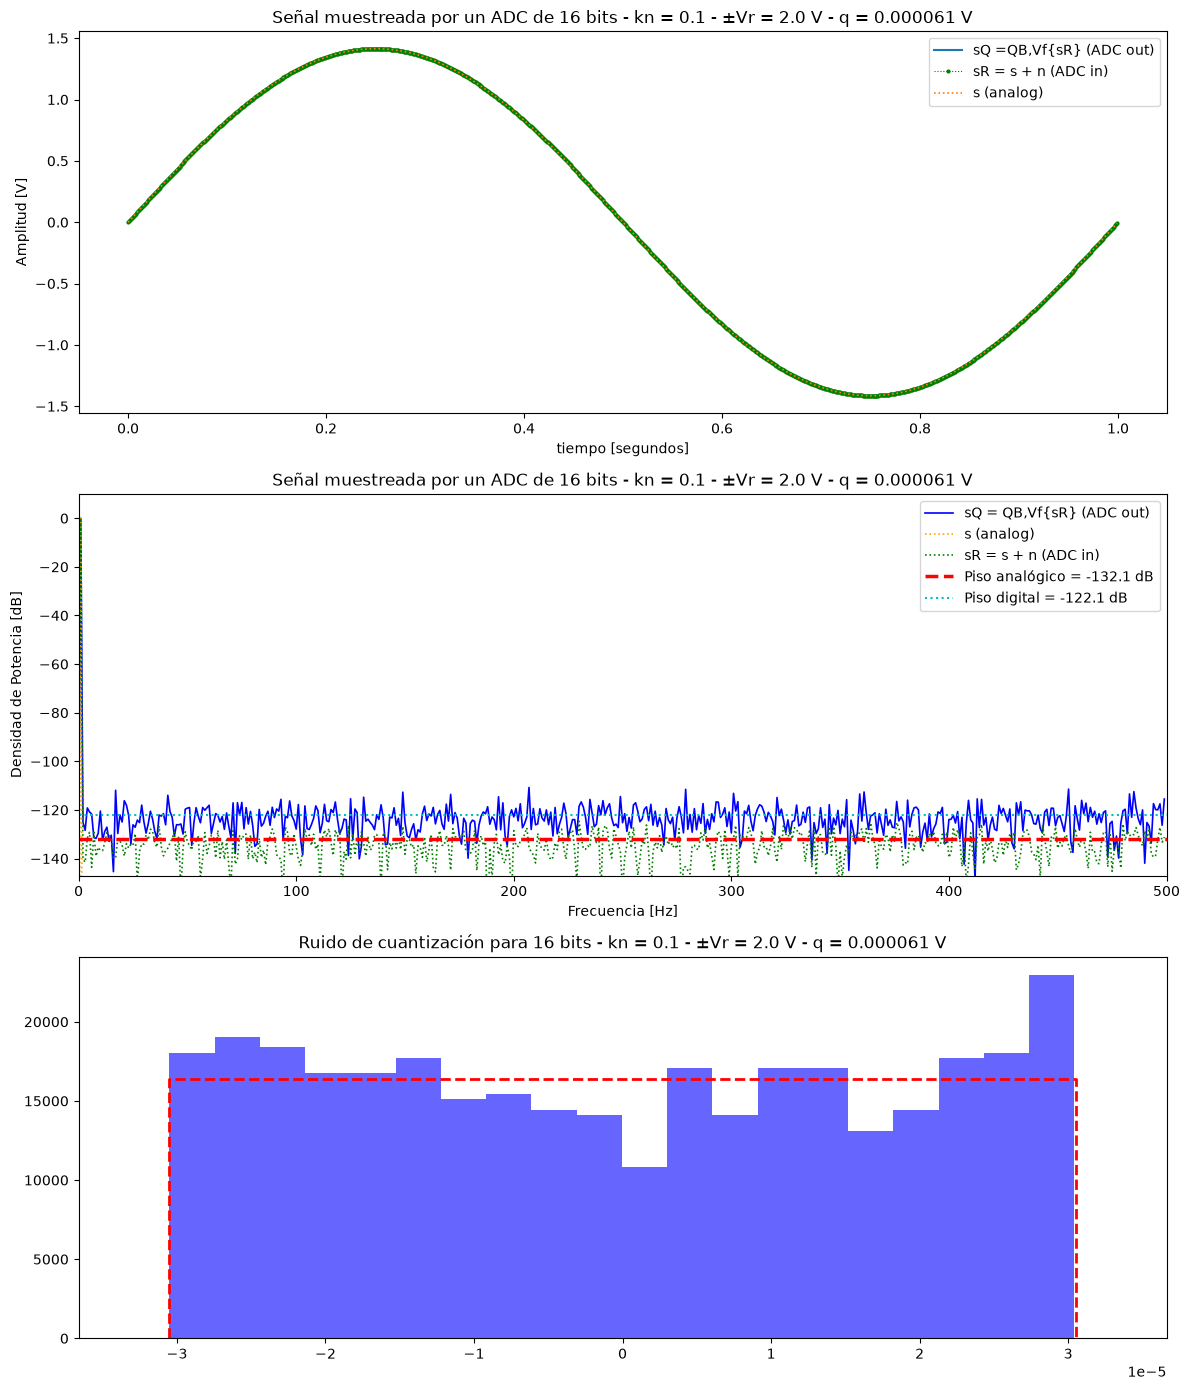

B = 16 - kn = 1
Piso analogico: -122.06991128975118 dB
Piso digital: -122.06991128975118 dB


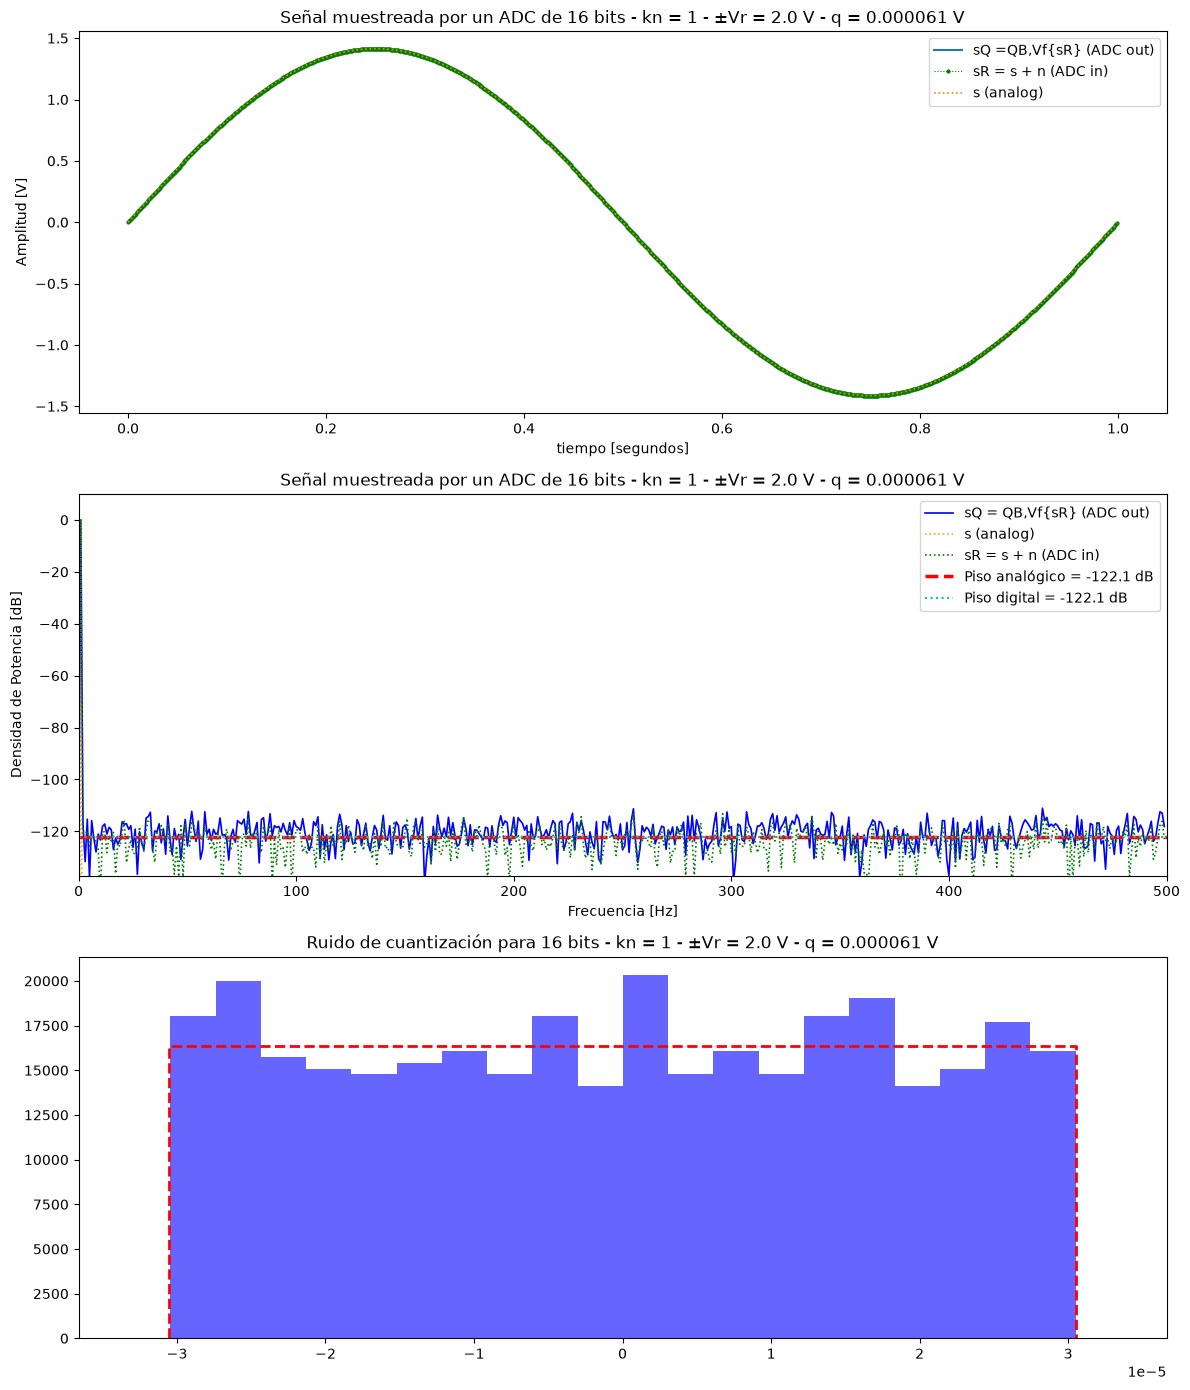

B = 16 - kn = 10
Piso analogico: -112.06991128975118 dB
Piso digital: -122.06991128975118 dB


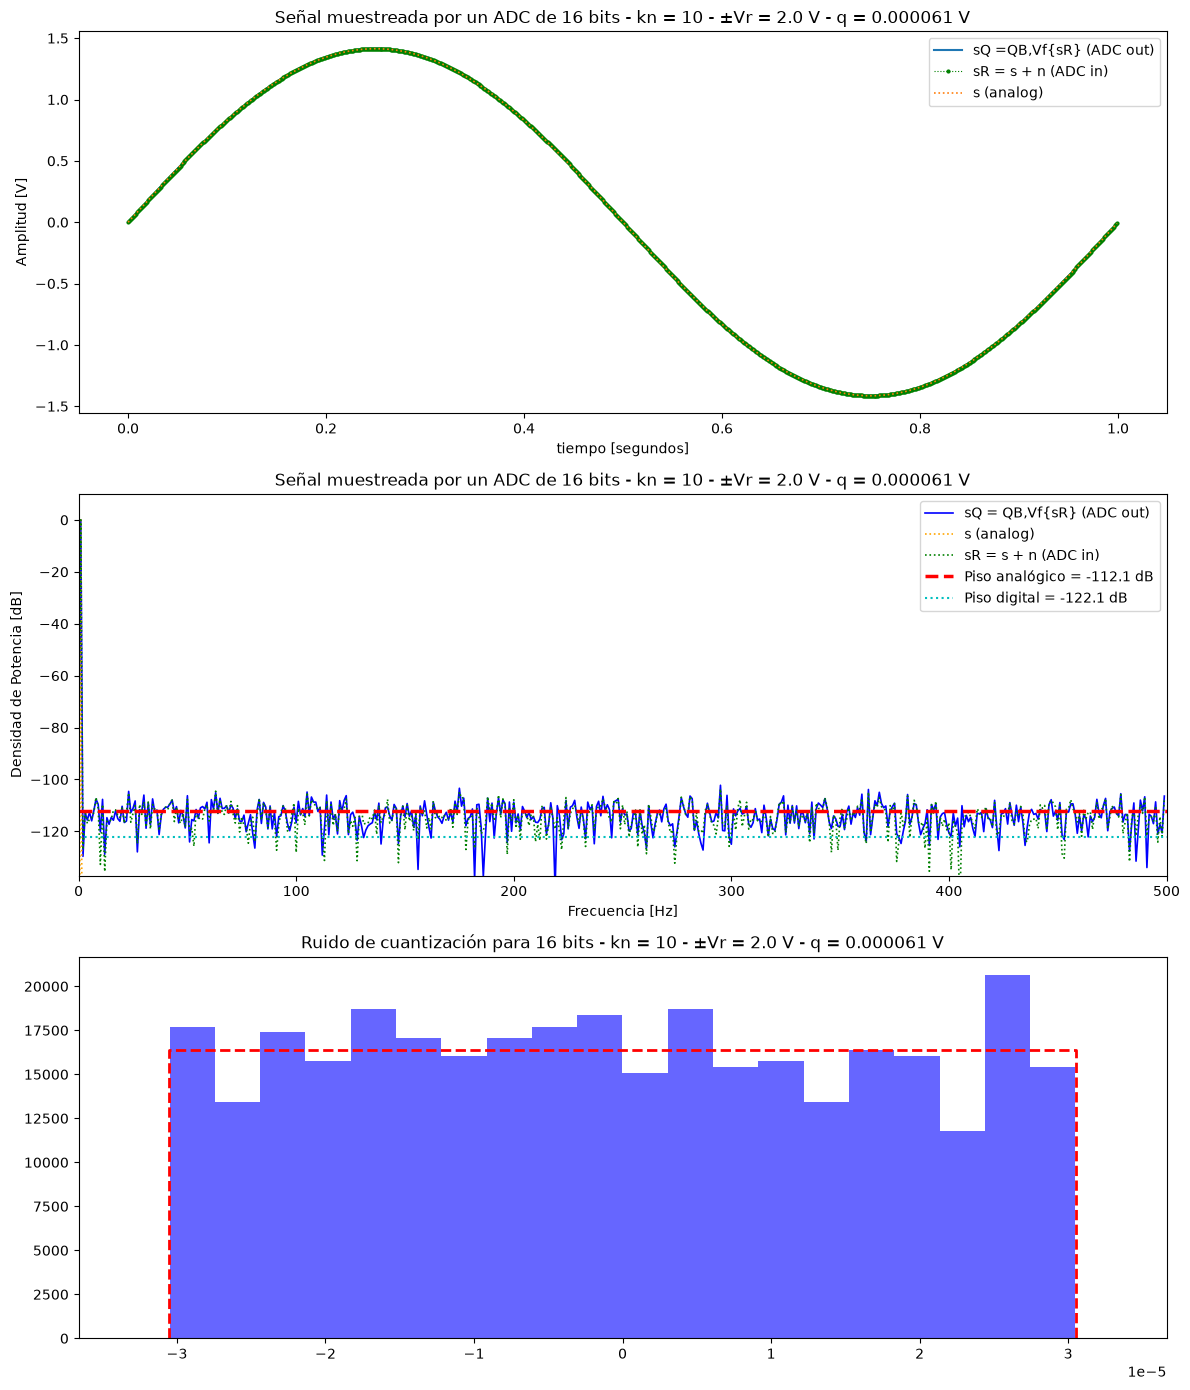

In [11]:
valores_B = [4, 8, 16]
valores_kn = [0.1, 1, 10]

for B in valores_B:
    for kn in valores_kn:
        if B == 4 and kn == 1: #este caso ya lo hice en el inciso A
           continue
        print("B =", B, "- kn =", kn)
        
        tt, xx = mi_funcion_sen(vmax, dc, f0, ph, N, fs)
        q = (2*vf)/(2**B) #paso de cuantizacion
        Pq= (q**2)/12 #potencia de cuantizacion
        Pr= kn*Pq #potencia de ruido
        desvio = np.sqrt(Pr)
        ruido = np.random.normal(0, desvio, N)
        #senal
        ruido_xx = xx + ruido
        ruido_xx_q = q * np.round(ruido_xx / q) #cuantizacion
        #vector de frecuencias
        ff_vec = np.fft.fftfreq(N, 1/fs)
        ff_vec = ff_vec[:N//2] #me quedo con las frecuencias positivas hasta Nyquist
        #espectros
        #senal
        XX = np.fft.fft(xx)/N
        XX= XX[:N//2] #mismo tamano que el vector de frecuencias
        PXX_mod = 2 * (np.abs(XX)**2)
        PXX_mod_db = 10 * np.log10(PXX_mod + 1e-30)
        #senal con ruido
        R_XX = np.fft.fft(ruido_xx)/N
        R_XX= R_XX[:N//2] #mismo tamano que el vector de frecuencias
        PR_XX_mod = 2 * (np.abs(R_XX)**2)
        PR_XX_mod_db = 10 * np.log10(PR_XX_mod + 1e-30)
        #senal con ruido cuantizada
        R_XX_Q = np.fft.fft(ruido_xx_q)/N
        R_XX_Q= R_XX_Q[:N//2] #mismo tamano que el vector de frecuencias
        PR_XX_Q_mod = 2 * (np.abs(R_XX_Q)**2)
        PR_XX_Q_mod_db = 10 * np.log10(PR_XX_Q_mod + 1e-30)

        #pisos de ruido
        piso_analogico = 10 * np.log10(Pr/(N/2))
        piso_digital = 10 * np.log10(Pq/(N/2))

        print("Piso analogico:", piso_analogico, "dB")
        print("Piso digital:", piso_digital, "dB")
        
        eq = ruido_xx_q - ruido_xx #error ruido de cuantizacion

        #graficos
        plt.figure(figsize=(12,14))
        
        #senal
        plt.subplot(3,1,1)
        plt.plot(tt, ruido_xx_q, label="sQ =QB,Vf{sR} (ADC out)")
        plt.plot(tt, ruido_xx, 'g:o', markersize=2, linewidth=0.8, label= "sR = s + n (ADC in)")
        plt.plot(tt, xx, ':',linewidth=1.2, label= "s (analog)")
        plt.title(f'Señal muestreada por un ADC de {B} bits - kn = {kn} - ±Vr = {vf:.1f} V - q = {q:.6f} V')
        plt.xlabel("tiempo [segundos]")
        plt.ylabel("Amplitud [V]")
        plt.legend()
        
        # espectros
        plt.subplot(3,1,2)
        plt.plot(ff_vec, PR_XX_Q_mod_db, color='b', linewidth=1.2,
                 label="sQ = QB,Vf{sR} (ADC out)")

        plt.plot(ff_vec, PXX_mod_db, color='orange', linestyle=':', linewidth=1.2,
                 label="s (analog)")

        plt.plot(ff_vec, PR_XX_mod_db, color='g', linestyle=':',linewidth=1.2,
                 label="sR = s + n (ADC in)")

        plt.axhline(piso_analogico, color='r', linestyle='--',linewidth=2.5,
                    label=f"Piso analógico = {piso_analogico:.1f} dB")

        plt.axhline(piso_digital, color='c', linestyle=':', linewidth=1.5,
                    label=f"Piso digital = {piso_digital:.1f} dB")

        plt.title(f'Señal muestreada por un ADC de {B} bits - kn = {kn} - ±Vr = {vf:.1f} V - q = {q:.6f} V')
        plt.xlabel("Frecuencia [Hz]")
        plt.ylabel("Densidad de Potencia [dB]")
        plt.xlim(0, fs/2)
        plt.ylim(min(piso_analogico, piso_digital)-15, 10)
        plt.legend()
        
        # histograma
        plt.subplot(3,1,3)
        plt.hist(eq, bins=20, density=True,
                 color='b', alpha=0.6)

        #distribucion uniforme teorica
        plt.plot([-q/2, -q/2, q/2, q/2],
                 [0, 1/q, 1/q, 0],
                 color='r', linestyle='--', linewidth=2)

        plt.title(f'Ruido de cuantización para {B} bits - kn = {kn} - ±Vr = {vf:.1f} V - q = {q:.6f} V')
        plt.xlim(-0.6*q, 0.6*q)

        plt.tight_layout()
        plt.show()

Al mantener fija la cantidad de bits y variar $kn$, se puede ver principalmente el efecto que tiene el ruido analógico. Para $B=4$, al pasar de $kn=0.1$ a $kn=10$, el piso de ruido analógico va aumentando, mientras que el piso de ruido digital se mantiene igual porque el paso de cuantización no cambia. Lo mismo ocurre para $B=8$ y $B=16$: cuando $kn=0.1$, el piso analógico queda por debajo del digital; cuando $kn=1$, ambos coinciden; y cuando $kn=10$, el piso analógico queda por encima.

Si ahora mantenemos fijo $kn$ y aumentamos la cantidad de bits, se observa que el paso de cuantización se hace cada vez más chico. Por eso disminuye la potencia del ruido de cuantización y también baja el piso de ruido digital. Como la potencia del ruido analógico se calcula a partir de $Pr=kn*Pq$, este ruido también disminuye al aumentar $B$. Esto se nota porque para 8 y sobre todo para 16 bits la señal cuantizada se parece mucho más a la señal original y los pisos de ruido aparecen a valores mucho más bajos.

También se puede ver este efecto en los histogramas del error de cuantización: al aumentar la cantidad de bits, el intervalo entre $-q/2$ y $q/2$ se hace cada vez más pequeño. En cambio, para una misma cantidad de bits, variar $kn$ no modifica ese intervalo, porque $q$ depende de $B$ y del rango del ADC, no del ruido analógico.

Para cerrar este trabajo, lo que más destaco es que permite conocer qué pasa realmente dentro de la cuantización de un ADC. Al ir cambiando la cantidad de bits pude ver que, cuanto mayor es $B$, más chico es el paso de cuantización y menor es el error que se introduce, haciendo que la señal de salida se parezca cada vez más a la original. También pude comprender que al modificar $kn$ cambia la relación entre el ruido analógico y el ruido de cuantización; por ejemplo, cuando $kn=1$, ambos tienen la misma potencia y por eso sus pisos de ruido coinciden. Finalmente, al analizar las señales tanto en el tiempo como en frecuencia y observar el histograma del error pudimos visualizar la teoria y calculos explicados en clase.